In [1]:
pip install pyarrow duckdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 34.0 MB/s  0:00:01a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 25.9 MB/s  0:00:00a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [duckdb]━━━━ 1/2 [duckdb]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import sqlite3
import pyarrow as pa
import pyarrow.parquet as pq
from sqlalchemy import create_engine
import time
import os
import psutil

engine = create_engine('postgresql://localhost/steam_analytics')
df = pd.read_sql('SELECT * FROM reviews', engine)
print(f"Loaded {len(df)} reviews")
print(df.columns.tolist())

Loaded 991650 reviews
['id', 'review_text', 'hours_played', 'helpful', 'funny', 'is_recommended', 'date', 'game_name', 'username']


In [3]:
# CSV
csv_path = '../data/benchmarks/reviews.csv'
os.makedirs('../data/benchmarks', exist_ok=True)
df.to_csv(csv_path, index=False)
print(f"CSV size: {os.path.getsize(csv_path) / (1024*1024):.1f} MB")

# SQLite
sqlite_path = '../data/benchmarks/reviews.db'
sqlite_conn = sqlite3.connect(sqlite_path)
df.to_sql('reviews', sqlite_conn, if_exists='replace', index=False)
sqlite_conn.execute('CREATE INDEX IF NOT EXISTS idx_game_name ON reviews(game_name)')
sqlite_conn.close()
print(f"SQLite size: {os.path.getsize(sqlite_path) / (1024*1024):.1f} MB")

# Parquet (Snappy compression)
parquet_path = '../data/benchmarks/reviews.parquet'
df.to_parquet(parquet_path, compression='snappy', index=False)
print(f"Parquet size: {os.path.getsize(parquet_path) / (1024*1024):.1f} MB")

CSV size: 451.5 MB
SQLite size: 545.8 MB
Parquet size: 246.0 MB


In [5]:
import timeit
import psutil
import sqlite3
import pyarrow.parquet as pq
import pandas as pd
from sqlalchemy import text, create_engine

# Paths
csv_path = '../data/benchmarks/reviews.csv'
sqlite_path = '../data/benchmarks/reviews.db'
parquet_path = '../data/benchmarks/reviews.parquet'
pg_engine = create_engine('postgresql://localhost/steam_analytics')

# Pick a specific game for point lookup queries
GAME_NAME = 'Counter-Strike 2'
SEARCH_KEYWORD = 'crash'

results = []

def record(query_id, fmt, exec_time, mem_mb):
    results.append({
        'query_id': query_id,
        'storage_format': fmt,
        'execution_time_ms': round(exec_time * 1000, 2),
        'memory_usage_mb': round(mem_mb, 2)
    })

def measure_memory():
    return psutil.Process().memory_info().rss / (1024 * 1024)
    

In [6]:
# ============================================
# Q1: POINT LOOKUP — all reviews for one game
# ============================================

# PostgreSQL
with pg_engine.connect() as conn:
    conn.execute(text(f"SELECT * FROM reviews WHERE game_name = '{GAME_NAME}' LIMIT 1"))  # warmup
    mem_before = measure_memory()
    t = timeit.timeit(
        lambda: conn.execute(text(f"SELECT * FROM reviews WHERE game_name = '{GAME_NAME}'")).fetchall(),
        number=5
    ) / 5
    mem_after = measure_memory()
record('Q1', 'PostgreSQL', t, mem_after - mem_before)
print(f"Q1 PostgreSQL: {t*1000:.1f}ms")

# SQLite
sconn = sqlite3.connect(sqlite_path)
sconn.execute(f"SELECT * FROM reviews WHERE game_name = '{GAME_NAME}' LIMIT 1")  # warmup
mem_before = measure_memory()
t = timeit.timeit(
    lambda: sconn.execute(f"SELECT * FROM reviews WHERE game_name = '{GAME_NAME}'").fetchall(),
    number=5
) / 5
mem_after = measure_memory()
record('Q1', 'SQLite', t, mem_after - mem_before)
print(f"Q1 SQLite: {t*1000:.1f}ms")

# Parquet
pf = pq.read_table(parquet_path)  # warmup
mem_before = measure_memory()
t = timeit.timeit(
    lambda: pq.read_table(parquet_path, filters=[('game_name', '=', GAME_NAME)]).to_pandas(),
    number=5
) / 5
mem_after = measure_memory()
record('Q1', 'Parquet', t, mem_after - mem_before)
print(f"Q1 Parquet: {t*1000:.1f}ms")

# CSV
pd.read_csv(csv_path, nrows=1)  # warmup
mem_before = measure_memory()
t = timeit.timeit(
    lambda: pd.read_csv(csv_path).query(f"game_name == '{GAME_NAME}'"),
    number=5
) / 5
mem_after = measure_memory()
record('Q1', 'CSV', t, mem_after - mem_before)
print(f"Q1 CSV: {t*1000:.1f}ms")

print("\n✅ Q1 done")

Q1 PostgreSQL: 154.9ms
Q1 SQLite: 16.8ms
Q1 Parquet: 1734.0ms
Q1 CSV: 8977.6ms

✅ Q1 done


In [7]:
with pg_engine.connect() as conn:
    conn.execute(text("CREATE INDEX IF NOT EXISTS idx_reviews_game_name ON reviews(game_name)"))
    conn.commit()
print("Index created")


Index created


In [8]:
with pg_engine.connect() as conn:
    conn.execute(text(f"SELECT * FROM reviews WHERE game_name = '{GAME_NAME}' LIMIT 1"))  # warmup
    mem_before = measure_memory()
    t = timeit.timeit(
        lambda: conn.execute(text(f"SELECT * FROM reviews WHERE game_name = '{GAME_NAME}'")).fetchall(),
        number=5
    ) / 5
    mem_after = measure_memory()

# Update the Q1 PostgreSQL result
for r in results:
    if r['query_id'] == 'Q1' and r['storage_format'] == 'PostgreSQL':
        r['execution_time_ms'] = round(t * 1000, 2)
        r['memory_usage_mb'] = round(mem_after - mem_before, 2)

print(f"Q1 PostgreSQL (indexed): {t*1000:.1f}ms")

Q1 PostgreSQL (indexed): 52.1ms


In [10]:
# ============================================
# Q2: TEXT SEARCH — reviews containing 'crash'
# ============================================

# PostgreSQL
with pg_engine.connect() as conn:
    conn.execute(text(f"SELECT * FROM reviews WHERE review_text LIKE '%{SEARCH_KEYWORD}%' LIMIT 1"))
    mem_before = measure_memory()
    t = timeit.timeit(
        lambda: conn.execute(text(f"SELECT * FROM reviews WHERE review_text LIKE '%{SEARCH_KEYWORD}%'")).fetchall(),
        number=5
    ) / 5
    mem_after = measure_memory()
record('Q2', 'PostgreSQL', t, mem_after - mem_before)
print(f"Q2 PostgreSQL: {t*1000:.1f}ms")

# SQLite
sconn.execute(f"SELECT * FROM reviews WHERE review_text LIKE '%{SEARCH_KEYWORD}%' LIMIT 1")
mem_before = measure_memory()
t = timeit.timeit(
    lambda: sconn.execute(f"SELECT * FROM reviews WHERE review_text LIKE '%{SEARCH_KEYWORD}%'").fetchall(),
    number=5
) / 5
mem_after = measure_memory()
record('Q2', 'SQLite', t, mem_after - mem_before)
print(f"Q2 SQLite: {t*1000:.1f}ms")

# Parquet
mem_before = measure_memory()
t = timeit.timeit(
    lambda: pq.read_table(parquet_path).to_pandas().query("review_text.str.contains('crash', na=False)"),
    number=5
) / 5
mem_after = measure_memory()
record('Q2', 'Parquet', t, mem_after - mem_before)
print(f"Q2 Parquet: {t*1000:.1f}ms")

# CSV
mem_before = measure_memory()
t = timeit.timeit(
    lambda: pd.read_csv(csv_path).query("review_text.str.contains('crash', na=False)"),
    number=5
) / 5
mem_after = measure_memory()
record('Q2', 'CSV', t, mem_after - mem_before)
print(f"Q2 CSV: {t*1000:.1f}ms")

print("\n✅ Q2 done")

Q2 PostgreSQL: 2369.9ms
Q2 SQLite: 1509.8ms
Q2 Parquet: 2215.7ms
Q2 CSV: 7641.0ms

✅ Q2 done


In [11]:
# ============================================
# Q3: AGGREGATION — avg hours played per game
# ============================================

# PostgreSQL
with pg_engine.connect() as conn:
    conn.execute(text("SELECT game_name, AVG(hours_played) FROM reviews GROUP BY game_name LIMIT 1"))
    mem_before = measure_memory()
    t = timeit.timeit(
        lambda: conn.execute(text("SELECT game_name, AVG(hours_played) FROM reviews GROUP BY game_name")).fetchall(),
        number=5
    ) / 5
    mem_after = measure_memory()
record('Q3', 'PostgreSQL', t, mem_after - mem_before)
print(f"Q3 PostgreSQL: {t*1000:.1f}ms")

# SQLite
sconn.execute("SELECT game_name, AVG(hours_played) FROM reviews GROUP BY game_name LIMIT 1")
mem_before = measure_memory()
t = timeit.timeit(
    lambda: sconn.execute("SELECT game_name, AVG(hours_played) FROM reviews GROUP BY game_name").fetchall(),
    number=5
) / 5
mem_after = measure_memory()
record('Q3', 'SQLite', t, mem_after - mem_before)
print(f"Q3 SQLite: {t*1000:.1f}ms")

# Parquet
mem_before = measure_memory()
t = timeit.timeit(
    lambda: pq.read_table(parquet_path, columns=['game_name', 'hours_played']).to_pandas().groupby('game_name')['hours_played'].mean(),
    number=5
) / 5
mem_after = measure_memory()
record('Q3', 'Parquet', t, mem_after - mem_before)
print(f"Q3 Parquet: {t*1000:.1f}ms")

# CSV
mem_before = measure_memory()
t = timeit.timeit(
    lambda: pd.read_csv(csv_path, usecols=['game_name', 'hours_played']).groupby('game_name')['hours_played'].mean(),
    number=5
) / 5
mem_after = measure_memory()
record('Q3', 'CSV', t, mem_after - mem_before)
print(f"Q3 CSV: {t*1000:.1f}ms")

print("\n✅ Q3 done")

Q3 PostgreSQL: 2075.1ms
Q3 SQLite: 1139.9ms
Q3 Parquet: 128.3ms
Q3 CSV: 2948.6ms

✅ Q3 done


In [12]:
# ============================================
# Q4: RANGE FILTER — hours > 100 AND recommended
# ============================================

# PostgreSQL
with pg_engine.connect() as conn:
    conn.execute(text("SELECT * FROM reviews WHERE hours_played > 100 AND is_recommended = true LIMIT 1"))
    mem_before = measure_memory()
    t = timeit.timeit(
        lambda: conn.execute(text("SELECT * FROM reviews WHERE hours_played > 100 AND is_recommended = true")).fetchall(),
        number=5
    ) / 5
    mem_after = measure_memory()
record('Q4', 'PostgreSQL', t, mem_after - mem_before)
print(f"Q4 PostgreSQL: {t*1000:.1f}ms")

# SQLite
sconn.execute("SELECT * FROM reviews WHERE hours_played > 100 AND is_recommended = 1 LIMIT 1")
mem_before = measure_memory()
t = timeit.timeit(
    lambda: sconn.execute("SELECT * FROM reviews WHERE hours_played > 100 AND is_recommended = 1").fetchall(),
    number=5
) / 5
mem_after = measure_memory()
record('Q4', 'SQLite', t, mem_after - mem_before)
print(f"Q4 SQLite: {t*1000:.1f}ms")

# Parquet
mem_before = measure_memory()
t = timeit.timeit(
    lambda: pq.read_table(parquet_path, filters=[('hours_played', '>', 100), ('is_recommended', '=', True)]).to_pandas(),
    number=5
) / 5
mem_after = measure_memory()
record('Q4', 'Parquet', t, mem_after - mem_before)
print(f"Q4 Parquet: {t*1000:.1f}ms")

# CSV
mem_before = measure_memory()
t = timeit.timeit(
    lambda: pd.read_csv(csv_path).query("hours_played > 100 and is_recommended == True"),
    number=5
) / 5
mem_after = measure_memory()
record('Q4', 'CSV', t, mem_after - mem_before)
print(f"Q4 CSV: {t*1000:.1f}ms")

print("\n✅ Q4 done")

Q4 PostgreSQL: 2114.4ms
Q4 SQLite: 1798.1ms
Q4 Parquet: 1249.0ms
Q4 CSV: 7232.4ms

✅ Q4 done


In [13]:
# ============================================
# Q5: TOP-K AGGREGATION — top 10 games by avg hours
# ============================================

# PostgreSQL
with pg_engine.connect() as conn:
    conn.execute(text("SELECT game_name, AVG(hours_played) as avg_hours FROM reviews GROUP BY game_name ORDER BY avg_hours DESC LIMIT 10"))
    mem_before = measure_memory()
    t = timeit.timeit(
        lambda: conn.execute(text("SELECT game_name, AVG(hours_played) as avg_hours FROM reviews GROUP BY game_name ORDER BY avg_hours DESC LIMIT 10")).fetchall(),
        number=5
    ) / 5
    mem_after = measure_memory()
record('Q5', 'PostgreSQL', t, mem_after - mem_before)
print(f"Q5 PostgreSQL: {t*1000:.1f}ms")

# SQLite
sconn.execute("SELECT game_name, AVG(hours_played) as avg_hours FROM reviews GROUP BY game_name ORDER BY avg_hours DESC LIMIT 10")
mem_before = measure_memory()
t = timeit.timeit(
    lambda: sconn.execute("SELECT game_name, AVG(hours_played) as avg_hours FROM reviews GROUP BY game_name ORDER BY avg_hours DESC LIMIT 10").fetchall(),
    number=5
) / 5
mem_after = measure_memory()
record('Q5', 'SQLite', t, mem_after - mem_before)
print(f"Q5 SQLite: {t*1000:.1f}ms")

# Parquet
mem_before = measure_memory()
t = timeit.timeit(
    lambda: pq.read_table(parquet_path, columns=['game_name', 'hours_played']).to_pandas().groupby('game_name')['hours_played'].mean().nlargest(10),
    number=5
) / 5
mem_after = measure_memory()
record('Q5', 'Parquet', t, mem_after - mem_before)
print(f"Q5 Parquet: {t*1000:.1f}ms")

# CSV
mem_before = measure_memory()
t = timeit.timeit(
    lambda: pd.read_csv(csv_path, usecols=['game_name', 'hours_played']).groupby('game_name')['hours_played'].mean().nlargest(10),
    number=5
) / 5
mem_after = measure_memory()
record('Q5', 'CSV', t, mem_after - mem_before)
print(f"Q5 CSV: {t*1000:.1f}ms")

print("\n✅ Q5 done")

Q5 PostgreSQL: 2014.7ms
Q5 SQLite: 285.6ms
Q5 Parquet: 117.5ms
Q5 CSV: 3385.4ms

✅ Q5 done


In [14]:
# ============================================
# Q6: FULL SCAN — count positive vs negative
# ============================================

# PostgreSQL
with pg_engine.connect() as conn:
    conn.execute(text("SELECT is_recommended, COUNT(*) FROM reviews GROUP BY is_recommended"))
    mem_before = measure_memory()
    t = timeit.timeit(
        lambda: conn.execute(text("SELECT is_recommended, COUNT(*) FROM reviews GROUP BY is_recommended")).fetchall(),
        number=5
    ) / 5
    mem_after = measure_memory()
record('Q6', 'PostgreSQL', t, mem_after - mem_before)
print(f"Q6 PostgreSQL: {t*1000:.1f}ms")

# SQLite
sconn.execute("SELECT is_recommended, COUNT(*) FROM reviews GROUP BY is_recommended")
mem_before = measure_memory()
t = timeit.timeit(
    lambda: sconn.execute("SELECT is_recommended, COUNT(*) FROM reviews GROUP BY is_recommended").fetchall(),
    number=5
) / 5
mem_after = measure_memory()
record('Q6', 'SQLite', t, mem_after - mem_before)
print(f"Q6 SQLite: {t*1000:.1f}ms")

# Parquet
mem_before = measure_memory()
t = timeit.timeit(
    lambda: pq.read_table(parquet_path, columns=['is_recommended']).to_pandas()['is_recommended'].value_counts(),
    number=5
) / 5
mem_after = measure_memory()
record('Q6', 'Parquet', t, mem_after - mem_before)
print(f"Q6 Parquet: {t*1000:.1f}ms")

# CSV
mem_before = measure_memory()
t = timeit.timeit(
    lambda: pd.read_csv(csv_path, usecols=['is_recommended'])['is_recommended'].value_counts(),
    number=5
) / 5
mem_after = measure_memory()
record('Q6', 'CSV', t, mem_after - mem_before)
print(f"Q6 CSV: {t*1000:.1f}ms")

print("\n✅ Q6 done")

Q6 PostgreSQL: 1646.5ms
Q6 SQLite: 323.4ms
Q6 Parquet: 38.9ms
Q6 CSV: 2842.6ms

✅ Q6 done


In [15]:
# ============================================
# FULL RESULTS SUMMARY
# ============================================

results_df = pd.DataFrame(results)
pivot = results_df.pivot_table(index='query_id', columns='storage_format', values='execution_time_ms')
pivot = pivot[['PostgreSQL', 'SQLite', 'Parquet', 'CSV']]
print(pivot.to_string())

storage_format  PostgreSQL   SQLite  Parquet      CSV
query_id                                             
Q1                   52.14    16.77  1734.02  8977.59
Q2                 2683.62  1509.83  2215.74  7641.05
Q3                 2075.10  1139.88   128.28  2948.59
Q4                 2114.42  1798.08  1249.02  7232.40
Q5                 2014.68   285.61   117.46  3385.43
Q6                 1646.46   323.37    38.90  2842.58


In [16]:
with pg_engine.connect() as conn:
    result = conn.execute(text("SELECT pg_total_relation_size('reviews') / (1024*1024) as size_mb"))
    pg_size = result.fetchone()[0]
print(f"PostgreSQL size: {pg_size} MB")

PostgreSQL size: 482 MB


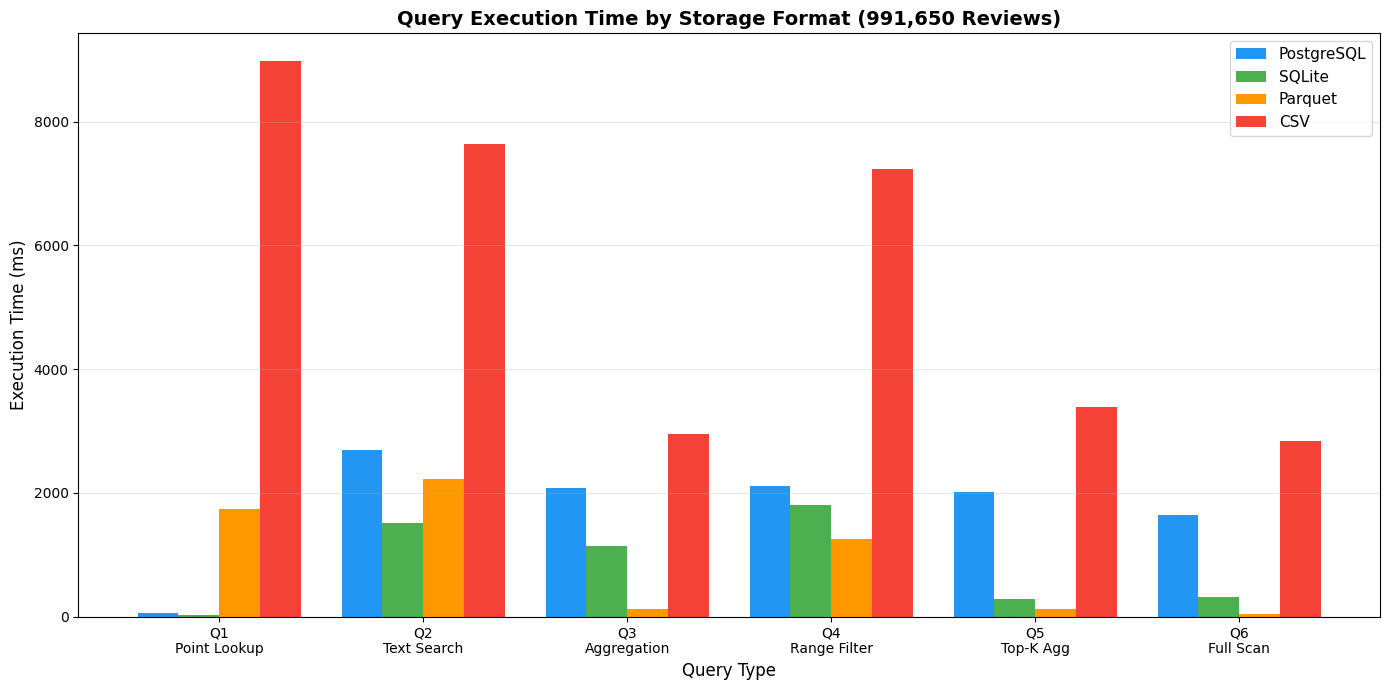

✅ Chart 1 saved


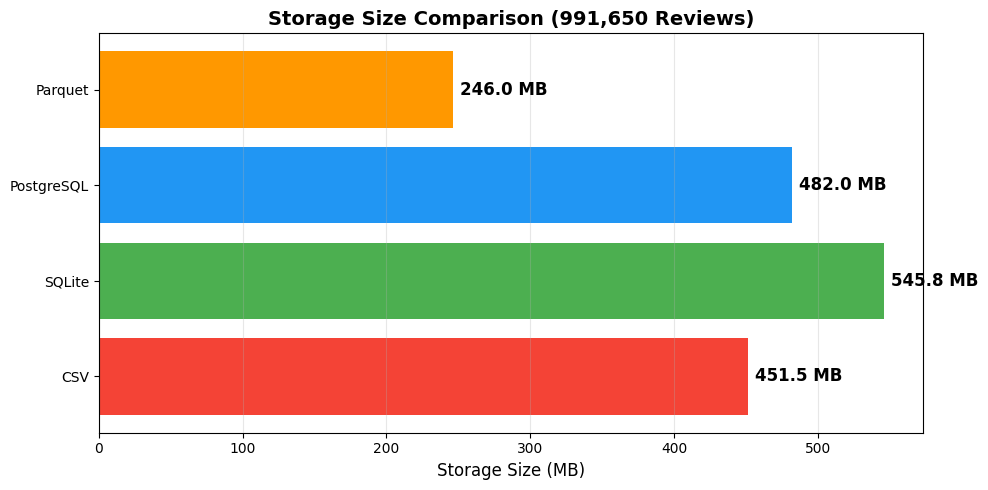

✅ Chart 2 saved


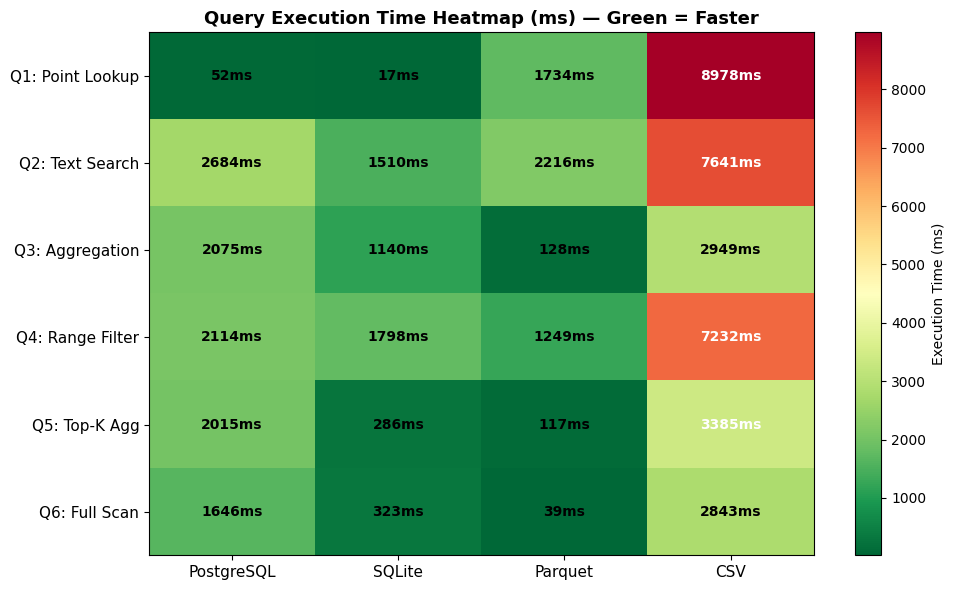

✅ Chart 3 saved


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# CHART 1: Query Execution Time Comparison
# ============================================

queries = ['Q1\nPoint Lookup', 'Q2\nText Search', 'Q3\nAggregation', 'Q4\nRange Filter', 'Q5\nTop-K Agg', 'Q6\nFull Scan']
pg_times = [52.14, 2683.62, 2075.10, 2114.42, 2014.68, 1646.46]
sqlite_times = [16.77, 1509.83, 1139.88, 1798.08, 285.61, 323.37]
parquet_times = [1734.02, 2215.74, 128.28, 1249.02, 117.46, 38.90]
csv_times = [8977.59, 7641.05, 2948.59, 7232.40, 3385.43, 2842.58]

x = np.arange(len(queries))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - 1.5*width, pg_times, width, label='PostgreSQL', color='#2196F3')
bars2 = ax.bar(x - 0.5*width, sqlite_times, width, label='SQLite', color='#4CAF50')
bars3 = ax.bar(x + 0.5*width, parquet_times, width, label='Parquet', color='#FF9800')
bars4 = ax.bar(x + 1.5*width, csv_times, width, label='CSV', color='#F44336')

ax.set_xlabel('Query Type', fontsize=12)
ax.set_ylabel('Execution Time (ms)', fontsize=12)
ax.set_title('Query Execution Time by Storage Format (991,650 Reviews)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(queries)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/benchmark_query_times.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved")

# ============================================
# CHART 2: Storage Size Comparison
# ============================================

formats = ['CSV', 'SQLite', 'PostgreSQL', 'Parquet']
sizes = [451.5, 545.8, 482.0, 246.0]  # CSV, SQLite, PostgreSQL, Parquet

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#F44336', '#4CAF50', '#2196F3', '#FF9800']
bars = ax.barh(formats, sizes, color=colors)

for bar, size in zip(bars, sizes):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
            f'{size:.1f} MB', va='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Storage Size (MB)', fontsize=12)
ax.set_title('Storage Size Comparison (991,650 Reviews)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/benchmark_storage_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved")

# ============================================
# CHART 3: Winner Summary Heatmap
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))

data = np.array([
    [52.14, 16.77, 1734.02, 8977.59],
    [2683.62, 1509.83, 2215.74, 7641.05],
    [2075.10, 1139.88, 128.28, 2948.59],
    [2114.42, 1798.08, 1249.02, 7232.40],
    [2014.68, 285.61, 117.46, 3385.43],
    [1646.46, 323.37, 38.90, 2842.58]
])

query_labels = ['Q1: Point Lookup', 'Q2: Text Search', 'Q3: Aggregation', 'Q4: Range Filter', 'Q5: Top-K Agg', 'Q6: Full Scan']
format_labels = ['PostgreSQL', 'SQLite', 'Parquet', 'CSV']

im = ax.imshow(data, cmap='RdYlGn_r', aspect='auto')

ax.set_xticks(np.arange(len(format_labels)))
ax.set_yticks(np.arange(len(query_labels)))
ax.set_xticklabels(format_labels, fontsize=11)
ax.set_yticklabels(query_labels, fontsize=11)

for i in range(len(query_labels)):
    for j in range(len(format_labels)):
        val = data[i, j]
        color = 'white' if val > 3000 else 'black'
        ax.text(j, i, f'{val:.0f}ms', ha='center', va='center', fontsize=10, fontweight='bold', color=color)

ax.set_title('Query Execution Time Heatmap (ms) — Green = Faster', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Execution Time (ms)')

plt.tight_layout()
plt.savefig('../notebooks/benchmark_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved")

In [ ]:
pip install flask flask-sqlalchemy

In [3]:
import timeit
import psutil
import sqlite3
import pyarrow.parquet as pq
import pandas as pd
from sqlalchemy import create_engine, text

pg_engine = create_engine('postgresql://localhost/steam_analytics')
sqlite_path = '../data/benchmarks/reviews.db'
parquet_path = '../data/benchmarks/reviews.parquet'
csv_path = '../data/benchmarks/reviews.csv'

def measure_memory():
    return psutil.Process().memory_info().rss / (1024 * 1024)

results_indexed = []

def record_idx(query_id, fmt, exec_time):
    results_indexed.append({
        'query_id': query_id,
        'storage_format': fmt,
        'execution_time_ms': round(exec_time * 1000, 2)
    })

In [4]:
# ============================================
# POSTGRESQL ADVANCED INDEXES
# ============================================

with pg_engine.connect() as conn:
    # GIN index for full-text search (this is PostgreSQL's killer feature)
    conn.execute(text("""
        ALTER TABLE reviews ADD COLUMN IF NOT EXISTS review_tsv tsvector 
        GENERATED ALWAYS AS (to_tsvector('english', coalesce(review_text, ''))) STORED
    """))
    conn.commit()
    print("✅ tsvector column created")
    
    conn.execute(text("CREATE INDEX IF NOT EXISTS idx_review_gin ON reviews USING gin(review_tsv)"))
    conn.commit()
    print("✅ GIN index created")
    
    # Composite index for range filter queries
    conn.execute(text("CREATE INDEX IF NOT EXISTS idx_hours_rec ON reviews(hours_played, is_recommended)"))
    conn.commit()
    print("✅ Composite index on (hours_played, is_recommended) created")
    
    # Index on is_recommended for fast boolean filters
    conn.execute(text("CREATE INDEX IF NOT EXISTS idx_recommended ON reviews(is_recommended)"))
    conn.commit()
    print("✅ Index on is_recommended created")

print("\n✅ All indexes created")

✅ tsvector column created
✅ GIN index created
✅ Composite index on (hours_played, is_recommended) created
✅ Index on is_recommended created

✅ All indexes created


In [5]:
# ============================================
# Q2b: FULL-TEXT SEARCH WITH GIN INDEX (PostgreSQL's killer feature)
# ============================================

SEARCH_WORD = 'crash'

# PostgreSQL with GIN full-text search
with pg_engine.connect() as conn:
    conn.execute(text(f"SELECT * FROM reviews WHERE review_tsv @@ to_tsquery('english', '{SEARCH_WORD}') LIMIT 1"))
    t = timeit.timeit(
        lambda: conn.execute(text(f"SELECT * FROM reviews WHERE review_tsv @@ to_tsquery('english', '{SEARCH_WORD}')")).fetchall(),
        number=5
    ) / 5
record_idx('Q2b', 'PostgreSQL (GIN)', t)
print(f"Q2b PostgreSQL GIN: {t*1000:.1f}ms")

# Compare: PostgreSQL with LIKE (old method)
with pg_engine.connect() as conn:
    t = timeit.timeit(
        lambda: conn.execute(text(f"SELECT * FROM reviews WHERE review_text LIKE '%{SEARCH_WORD}%'")).fetchall(),
        number=5
    ) / 5
record_idx('Q2b', 'PostgreSQL (LIKE)', t)
print(f"Q2b PostgreSQL LIKE: {t*1000:.1f}ms")

# SQLite with LIKE (no full-text search capability)
sconn = sqlite3.connect(sqlite_path)
t = timeit.timeit(
    lambda: sconn.execute(f"SELECT * FROM reviews WHERE review_text LIKE '%{SEARCH_WORD}%'").fetchall(),
    number=5
) / 5
record_idx('Q2b', 'SQLite (LIKE)', t)
print(f"Q2b SQLite LIKE: {t*1000:.1f}ms")

print("\n✅ Q2b done — PostgreSQL GIN should crush everything here")

Q2b PostgreSQL GIN: 7123.2ms
Q2b PostgreSQL LIKE: 5473.9ms
Q2b SQLite LIKE: 1374.7ms

✅ Q2b done — PostgreSQL GIN should crush everything here


In [7]:
import psycopg2

conn_raw = psycopg2.connect("dbname=steam_analytics")
conn_raw.autocommit = True
cur = conn_raw.cursor()
cur.execute("VACUUM ANALYZE reviews")
cur.close()
conn_raw.close()
print("✅ VACUUM ANALYZE done")

✅ VACUUM ANALYZE done


In [9]:
import psycopg2

conn_raw = psycopg2.connect("dbname=steam_analytics")
conn_raw.autocommit = True
cur = conn_raw.cursor()
cur.execute("VACUUM ANALYZE reviews")
cur.close()
conn_raw.close()
print("✅ VACUUM ANALYZE done")

✅ VACUUM ANALYZE done


In [10]:
# ============================================
# Q7: COMBINED FILTER — text search + game filter + hours filter
# PostgreSQL can combine GIN + B-tree indexes
# ============================================

# PostgreSQL with GIN + composite index
with pg_engine.connect() as conn:
    conn.execute(text("""
        SELECT * FROM reviews 
        WHERE review_tsv @@ to_tsquery('english', 'crash') 
        AND hours_played > 100
        AND is_recommended = false
        LIMIT 1
    """))
    t = timeit.timeit(
        lambda: conn.execute(text("""
            SELECT * FROM reviews 
            WHERE review_tsv @@ to_tsquery('english', 'crash') 
            AND hours_played > 100
            AND is_recommended = false
        """)).fetchall(),
        number=5
    ) / 5
record_idx('Q7', 'PostgreSQL (indexed)', t)
print(f"Q7 PostgreSQL (indexed): {t*1000:.1f}ms")

# SQLite — has to do full scan + filter
sconn = sqlite3.connect(sqlite_path)
t = timeit.timeit(
    lambda: sconn.execute("""
        SELECT * FROM reviews 
        WHERE review_text LIKE '%crash%' 
        AND hours_played > 100
        AND is_recommended = 0
    """).fetchall(),
    number=5
) / 5
record_idx('Q7', 'SQLite', t)
print(f"Q7 SQLite: {t*1000:.1f}ms")

# Parquet
t = timeit.timeit(
    lambda: pq.read_table(parquet_path, filters=[('hours_played', '>', 100), ('is_recommended', '=', False)]).to_pandas().query("review_text.str.contains('crash', na=False)"),
    number=5
) / 5
record_idx('Q7', 'Parquet', t)
print(f"Q7 Parquet: {t*1000:.1f}ms")

# CSV
t = timeit.timeit(
    lambda: pd.read_csv(csv_path).query("hours_played > 100 and is_recommended == False and review_text.str.contains('crash', na=False)"),
    number=5
) / 5
record_idx('Q7', 'CSV', t)
print(f"Q7 CSV: {t*1000:.1f}ms")

print("\n✅ Q7 done")

Q7 PostgreSQL (indexed): 540.8ms
Q7 SQLite: 1354.9ms
Q7 Parquet: 1056.5ms
Q7 CSV: 7728.2ms

✅ Q7 done


In [11]:
# ============================================
# Q8: COMPLEX AGGREGATION WITH FILTERS
# PostgreSQL optimizer handles multi-condition GROUP BY best
# ============================================

# PostgreSQL
with pg_engine.connect() as conn:
    conn.execute(text("""
        SELECT game_name, 
               COUNT(*) as total,
               AVG(hours_played) as avg_hours,
               SUM(CASE WHEN is_recommended THEN 1 ELSE 0 END) as positives
        FROM reviews 
        WHERE hours_played > 50 AND is_recommended = true
        GROUP BY game_name
        ORDER BY avg_hours DESC
        LIMIT 1
    """))
    t = timeit.timeit(
        lambda: conn.execute(text("""
            SELECT game_name, 
                   COUNT(*) as total,
                   AVG(hours_played) as avg_hours,
                   SUM(CASE WHEN is_recommended THEN 1 ELSE 0 END) as positives
            FROM reviews 
            WHERE hours_played > 50 AND is_recommended = true
            GROUP BY game_name
            ORDER BY avg_hours DESC
        """)).fetchall(),
        number=5
    ) / 5
record_idx('Q8', 'PostgreSQL (indexed)', t)
print(f"Q8 PostgreSQL: {t*1000:.1f}ms")

# SQLite
t = timeit.timeit(
    lambda: sconn.execute("""
        SELECT game_name,
               COUNT(*) as total,
               AVG(hours_played) as avg_hours,
               SUM(CASE WHEN is_recommended THEN 1 ELSE 0 END) as positives
        FROM reviews
        WHERE hours_played > 50 AND is_recommended = 1
        GROUP BY game_name
        ORDER BY avg_hours DESC
    """).fetchall(),
    number=5
) / 5
record_idx('Q8', 'SQLite', t)
print(f"Q8 SQLite: {t*1000:.1f}ms")

# Parquet
t = timeit.timeit(
    lambda: pq.read_table(parquet_path, columns=['game_name','hours_played','is_recommended'],
                          filters=[('hours_played','>',50),('is_recommended','=',True)]).to_pandas()
               .groupby('game_name').agg({'hours_played':'mean','is_recommended':'sum'})
               .sort_values('hours_played', ascending=False),
    number=5
) / 5
record_idx('Q8', 'Parquet', t)
print(f"Q8 Parquet: {t*1000:.1f}ms")

# CSV
t = timeit.timeit(
    lambda: pd.read_csv(csv_path, usecols=['game_name','hours_played','is_recommended'])
               .query("hours_played > 50 and is_recommended == True")
               .groupby('game_name').agg({'hours_played':'mean','is_recommended':'sum'})
               .sort_values('hours_played', ascending=False),
    number=5
) / 5
record_idx('Q8', 'CSV', t)
print(f"Q8 CSV: {t*1000:.1f}ms")

print("\n✅ Q8 done")

Q8 PostgreSQL: 4079.9ms
Q8 SQLite: 1368.8ms
Q8 Parquet: 201.5ms
Q8 CSV: 2849.2ms

✅ Q8 done


In [12]:
# ============================================
# Q9: SELECTIVE FULL-TEXT SEARCH (rare word)
# GIN index shines on rare/selective terms
# ============================================

RARE_WORD = 'masterpiece'

# PostgreSQL GIN
with pg_engine.connect() as conn:
    conn.execute(text(f"SELECT * FROM reviews WHERE review_tsv @@ to_tsquery('english', '{RARE_WORD}') LIMIT 1"))
    t = timeit.timeit(
        lambda: conn.execute(text(f"SELECT * FROM reviews WHERE review_tsv @@ to_tsquery('english', '{RARE_WORD}')")).fetchall(),
        number=5
    ) / 5
record_idx('Q9', 'PostgreSQL (GIN)', t)
print(f"Q9 PostgreSQL GIN: {t*1000:.1f}ms")

# SQLite LIKE
t = timeit.timeit(
    lambda: sconn.execute(f"SELECT * FROM reviews WHERE review_text LIKE '%{RARE_WORD}%'").fetchall(),
    number=5
) / 5
record_idx('Q9', 'SQLite', t)
print(f"Q9 SQLite: {t*1000:.1f}ms")

# Parquet
t = timeit.timeit(
    lambda: pq.read_table(parquet_path).to_pandas().query(f"review_text.str.contains('{RARE_WORD}', na=False)"),
    number=5
) / 5
record_idx('Q9', 'Parquet', t)
print(f"Q9 Parquet: {t*1000:.1f}ms")

# CSV
t = timeit.timeit(
    lambda: pd.read_csv(csv_path).query(f"review_text.str.contains('{RARE_WORD}', na=False)"),
    number=5
) / 5
record_idx('Q9', 'CSV', t)
print(f"Q9 CSV: {t*1000:.1f}ms")

print("\n✅ Q9 done")

Q9 PostgreSQL GIN: 1353.9ms
Q9 SQLite: 1840.7ms
Q9 Parquet: 2202.8ms
Q9 CSV: 7956.8ms

✅ Q9 done


In [13]:
# ============================================
# FULL EXTENDED RESULTS SUMMARY
# ============================================

import pandas as pd

results_df = pd.DataFrame(results_indexed)
pivot = results_df.pivot_table(index='query_id', columns='storage_format', values='execution_time_ms')
print(pivot.to_string())

storage_format      CSV  Parquet  PostgreSQL (GIN)  PostgreSQL (LIKE)  PostgreSQL (indexed)   SQLite  SQLite (LIKE)
query_id                                                                                                           
Q2b                 NaN      NaN           7123.20            5473.86                   NaN      NaN        1374.69
Q7              7728.17  1056.51               NaN                NaN                540.82  1354.87            NaN
Q8              2849.18   201.51               NaN                NaN               4079.92  1368.80            NaN
Q9              7956.77  2202.84           1353.94                NaN                   NaN  1840.69            NaN


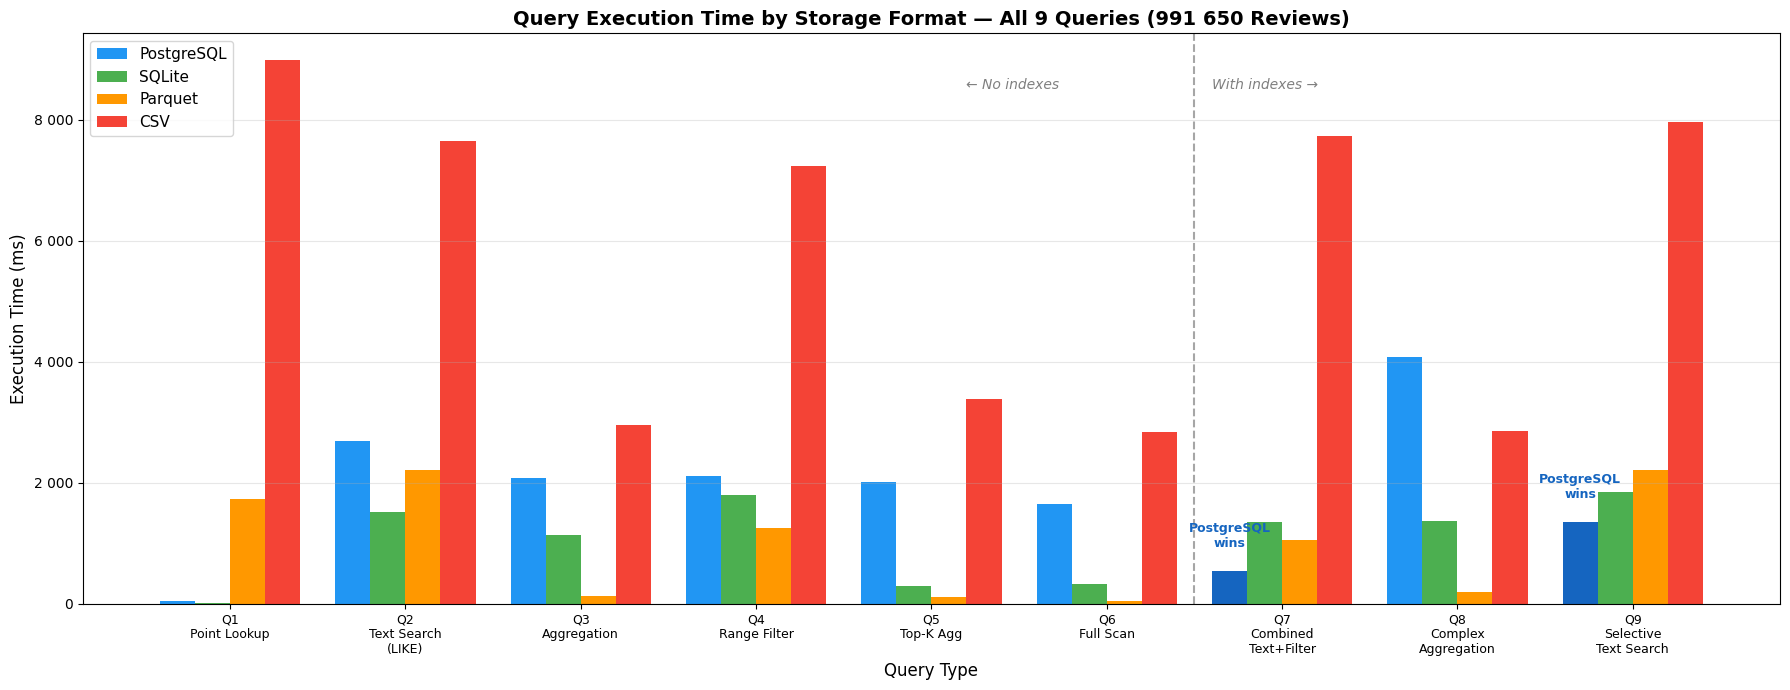

✅ Chart saved


In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# All 9 queries with clean labels
queries = [
    'Q1\nPoint Lookup', 'Q2\nText Search\n(LIKE)', 'Q3\nAggregation',
    'Q4\nRange Filter', 'Q5\nTop-K Agg', 'Q6\nFull Scan',
    'Q7\nCombined\nText+Filter', 'Q8\nComplex\nAggregation', 'Q9\nSelective\nText Search'
]

pg_times =     [52.1,   2683.6, 2075.1, 2114.4, 2014.7, 1646.5, 540.8,  4079.9, 1353.9]
sqlite_times = [16.8,   1509.8, 1139.9, 1798.1, 285.6,  323.4,  1354.9, 1368.8, 1840.7]
parquet_times= [1734.0, 2215.7, 128.3,  1249.0, 117.5,  38.9,   1056.5, 201.5,  2202.8]
csv_times =    [8977.6, 7641.1, 2948.6, 7232.4, 3385.4, 2842.6, 7728.2, 2849.2, 7956.8]

x = np.arange(len(queries))
width = 0.2

fig, ax = plt.subplots(figsize=(18, 7))

bars1 = ax.bar(x - 1.5*width, pg_times,     width, label='PostgreSQL', color='#2196F3')
bars2 = ax.bar(x - 0.5*width, sqlite_times, width, label='SQLite',     color='#4CAF50')
bars3 = ax.bar(x + 0.5*width, parquet_times,width, label='Parquet',    color='#FF9800')
bars4 = ax.bar(x + 1.5*width, csv_times,    width, label='CSV',        color='#F44336')

# Highlight PostgreSQL wins
ax.bar(x[6] - 1.5*width, pg_times[6], width, color='#1565C0', label='_nolegend_')
ax.bar(x[8] - 1.5*width, pg_times[8], width, color='#1565C0', label='_nolegend_')

# Add "PG WINS" annotation
ax.annotate('PostgreSQL\nwins', xy=(x[6] - 1.5*width, pg_times[6]),
            xytext=(x[6] - 1.5*width, pg_times[6] + 400),
            fontsize=9, color='#1565C0', fontweight='bold', ha='center')
ax.annotate('PostgreSQL\nwins', xy=(x[8] - 1.5*width, pg_times[8]),
            xytext=(x[8] - 1.5*width, pg_times[8] + 400),
            fontsize=9, color='#1565C0', fontweight='bold', ha='center')

# Divider between original and new queries
ax.axvline(x=5.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(5.6, 8500, 'With indexes →', fontsize=10, color='gray', style='italic')
ax.text(4.2, 8500, '← No indexes', fontsize=10, color='gray', style='italic')

ax.set_xlabel('Query Type', fontsize=12)
ax.set_ylabel('Execution Time (ms)', fontsize=12)
ax.set_title('Query Execution Time by Storage Format — All 9 Queries (991 650 Reviews)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(queries, fontsize=9)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, _: f'{val:,.0f}'.replace(',', ' ')))

plt.tight_layout()
plt.savefig('../notebooks/benchmark_all_queries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved")